In [1]:
!pip install alibi==0.9.5 shap tensorflow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Use tf.keras throughout instead of bare keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras import optimizers

import cv2


In [2]:
import shutil
shutil.copy(
    "/content/drive/MyDrive/Explainability Exercise/explanation_template.html",
    "/content/explanation_template.html"
)

'/content/explanation_template.html'

In [3]:
# Load data
train = pd.read_csv('/content/drive/MyDrive/Explainability Exercise/data/train.csv')
test = pd.read_csv('/content/drive/MyDrive/Explainability Exercise/data/test.csv')
print('Number of train samples: ', train.shape[0])
print('Number of test samples: ', test.shape[0])

# Preprocecss data
train["id_code"] = train["id_code"].apply(lambda x: x + ".png")
test["id_code"] = test["id_code"].apply(lambda x: x + ".png")
train['diagnosis'] = train['diagnosis'].astype('str')
test['diagnosis'] = test['diagnosis'].astype('str')
display(train.head())
display(test.head())

Number of train samples:  2929
Number of test samples:  733


,id_code,age,gender,diagnosis
0,e8ddfc9709ce.png,55,F,0
1,c1437a7a52c9.png,64,F,0
2,b8ebedd382de.png,31,M,1
3,9859e2a6cc24.png,62,M,4
4,66b88a4bc474.png,78,F,0


,id_code,age,gender,diagnosis
0,04aef84a2cc1.png,75,F,0
1,4ad8d3ec8789.png,26,F,0
2,cb02bb47fdc5.png,71,F,0
3,c9d42d7534e0.png,70,M,2
4,d5a39339ff3d.png,19,F,2


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Model parameters
BATCH_SIZE = 8
HEIGHT = 320
WIDTH = 320
CANAL = 3
N_CLASSES = train['diagnosis'].nunique()
N_CLASSES = test['diagnosis'].nunique()

In [6]:
# Data generators

train_datagen=ImageDataGenerator(rescale=1./255,
                                 rotation_range=360,
                                 horizontal_flip=True,
                                 vertical_flip=True)

train_generator=train_datagen.flow_from_dataframe(
    dataframe=train,
    directory="/content/drive/MyDrive/Explainability Exercise/data/train_images/",
    x_col="id_code",
    y_col="diagnosis",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    target_size=(HEIGHT, WIDTH),
    seed=0)

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_dataframe(
        dataframe=test,
        directory = "/content/drive/MyDrive/Explainability Exercise/data/test_images/",
        x_col="id_code",
        y_col="diagnosis",
        class_mode="categorical",
        batch_size=BATCH_SIZE,
        target_size=(HEIGHT, WIDTH),
        seed=0)


Found 923 validated image filenames belonging to 5 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:918: UserWarning: Found 2006 invalid image filename(s) in x_col="id_code". These filename(s) will be ignored.
  warnings.warn(


Found 633 validated image filenames belonging to 5 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:918: UserWarning: Found 100 invalid image filename(s) in x_col="id_code". These filename(s) will be ignored.
  warnings.warn(


In [7]:
# Generate 20 test data points

test_generator.batch_size = 20 # background dataset
data, labels = next(test_generator)

[1. 0. 0. 0. 0.]


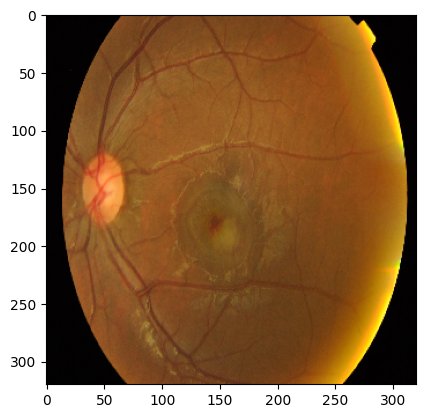

[0. 0. 1. 0. 0.]


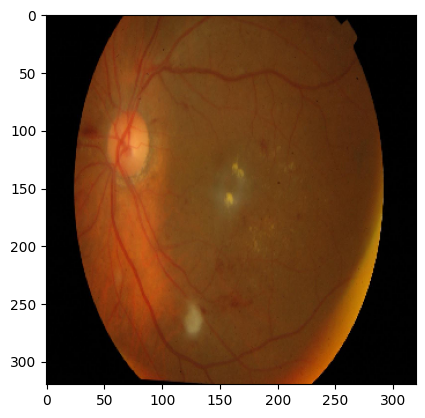

[1. 0. 0. 0. 0.]


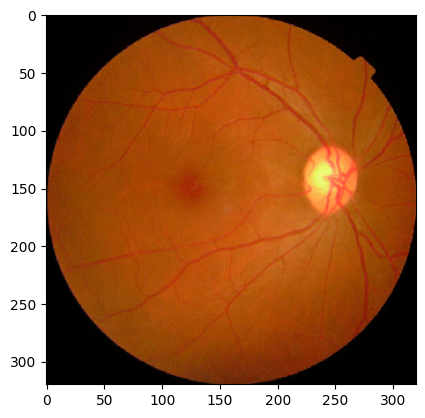

[1. 0. 0. 0. 0.]


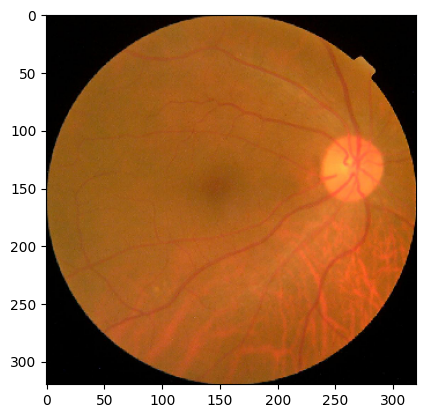

[0. 0. 0. 1. 0.]


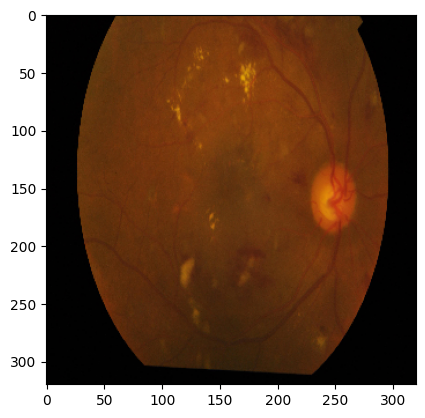

In [8]:
# View some images and labels

plt.imshow(data[0])
print(labels[0])
plt.show()

plt.imshow(data[1])
print(labels[1])
plt.show()

plt.imshow(data[2])
print(labels[2])
plt.show()

plt.imshow(data[3])
print(labels[3])
plt.show()

plt.imshow(data[4])
print(labels[4])
plt.show()

In [9]:
# Load model
model = tf.keras.models.load_model("/content/drive/MyDrive/Explainability Exercise/model.h5", compile=False)

In [10]:
# Generate some predictions

predictions = model.predict(data).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step


0
[1. 0. 0. 0. 0.]


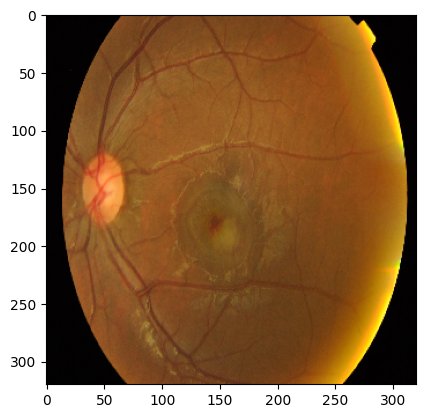

2
[0. 0. 1. 0. 0.]


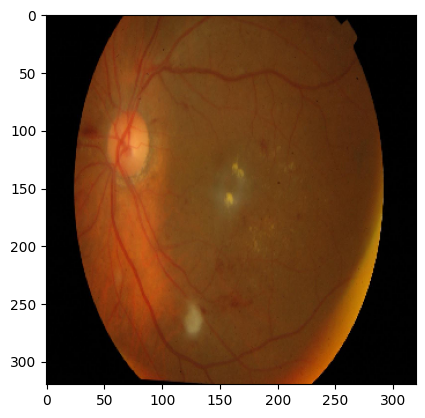

0
[0. 0. 1. 0. 0.]


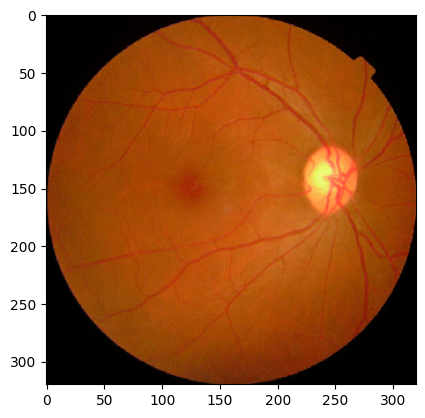

0
[0. 0. 1. 0. 0.]


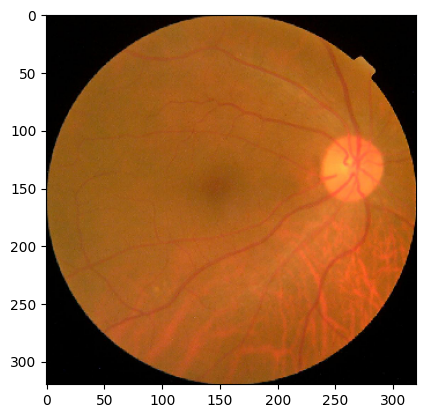

2
[0. 0. 1. 0. 0.]


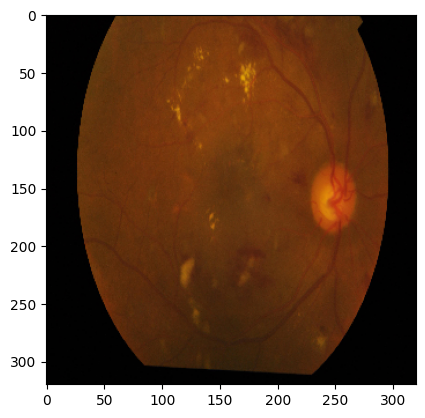

In [11]:
# View some predictions


plt.imshow(data[0])
print(predictions[0])
print(labels[0])
plt.show()

plt.imshow(data[1])
print(predictions[1])
print(labels[1])
plt.show()

plt.imshow(data[2])
print(predictions[2])
print(labels[1])
plt.show()

plt.imshow(data[3])
print(predictions[3])
print(labels[1])
plt.show()

plt.imshow(data[4])
print(predictions[4])
print(labels[1])
plt.show()

In [22]:
# Overwrite the template with the clean original
template_content = '''<!doctype html>
<html>
<head>
<title>Explanation Template</title>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<link rel="stylesheet" href="https://www.w3schools.com/w3css/4/w3.css">
</head>
<body>
<div class="w3-content w3-padding-large w3-margin-top" id="portfolio">
  <div class="w3-light-grey w3-padding-large w3-padding-32 w3-margin-top" id="prediction">
    <h3 class="w3-center">Diagnosis Report</h3>
    <hr>
    <p>Patient: PXX</p>
    <p>Gender: GXX</p>
    <p>Retinal Image</p>
    <img src="IMAGE_FOR_DISPLAY.png" alt="Retinal Image" class="w3-image" width="500">
    <p>Anchor Explanation</p>
    <img src="ANCHOR_FOR_DISPLAY.png" alt="Anchor Image" class="w3-image" width="800">
    <p>Diagnosis: DXX</p>
    <p>EXPLANATION</p>
  </div>
</div>
</body>
</html>'''

with open("/content/explanation_template.html", "w") as f:
    f.write(template_content)

print("✅ Template overwritten")

# Verify placeholders are there
html = open("/content/explanation_template.html").read()
print("PXX found:", "PXX" in html)
print("GXX found:", "GXX" in html)
print("DXX found:", "DXX" in html)

✅ Template overwritten
PXX found: True
GXX found: True
DXX found: True


In [13]:
# Generate explanations
import os, base64, shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.backends.backend_pdf import PdfPages
from alibi.explainers import AnchorImage

diagnosis_dict = {0: 'No DR',
                  1: 'Mild',
                  2: 'Moderate',
                  3: 'Severe',
                  4: 'Proliferative DR'}

action_dict = {
    0: 'No referral needed. Schedule next annual screening.',
    1: 'Schedule follow-up within 6–12 months.',
    2: 'Refer to ophthalmologist within 3 months.',
    3: 'Urgent referral to ophthalmologist within 4 weeks.',
    4: 'EMERGENCY: Refer same day / within 24 hours.'
}

# ── Helper: image file → base64 string ────────────────────
def image_to_base64(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

# ── Helper: save retinal image ─────────────────────────────
def save_retinal_image(image, save_path):
    """Save the raw retinal image as PNG."""
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(image[0])
    ax.axis('off')
    plt.tight_layout(pad=0)
    plt.savefig(save_path, bbox_inches='tight', dpi=120)
    plt.close()




In [27]:
# ── Helper: save retinal image ─────────────────────────────
def save_retinal_image(image, save_path):
    """Save the raw retinal image as PNG."""
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(image[0])
    ax.axis('off')
    plt.tight_layout(pad=0)
    plt.savefig(save_path, bbox_inches='tight', dpi=120)
    plt.close()

# ── Helper: run Anchor and save result ────────────────────
def save_anchor_image(image, save_path):
    """Run AnchorImage and save side-by-side original + anchor PNG."""

    def predict_fn(images):
        return model.predict(images.astype(np.float32) / 255.0, verbose=0)

    image_uint8 = (image[0] * 255).astype(np.uint8)

    anchor_explainer = AnchorImage(
        predict_fn,
        image_shape=(320, 320, 3),
        segmentation_fn='slic',
        segmentation_kwargs={
            'n_segments': 10,
            'compactness': 20,
            'sigma': 0.5
        }
    )

    exp = anchor_explainer.explain(image_uint8, threshold=0.90, p_sample=0.5)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(image_uint8)
    axes[0].set_title("Original Retinal Image", fontsize=11, fontweight='bold')
    axes[0].axis('off')
    axes[1].imshow(exp.anchor)
    axes[1].set_title(
        "Anchor: Key Regions\nHighlighted = sufficient to confirm prediction\nGreyed out = not needed",
        fontsize=10, fontweight='bold'
    )
    axes[1].axis('off')
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight', dpi=120)
    plt.close()

# ── Main HTML generator ────────────────────────────────────
def generate_html(filename, image, prediction, patient_id, gender, age):
    """
    Generate a self-contained HTML explanation for one patient.

    HOW TO USE FOR A NEW PATIENT:
      generate_html(
          filename   = "patient_NEW.html",
          image      = data[INDEX:INDEX+1],   # change INDEX (0-19)
          prediction = predictions[INDEX],     # same INDEX
          patient_id = "PT-XXX",
          gender     = "Male/Female",
          age        = 00
      )
    """

    # 1. Save and encode retinal image
    save_retinal_image(image, "/content/retinal_temp.png")
    retinal_b64 = image_to_base64("/content/retinal_temp.png")

    # 2. Run Anchor and encode result
    print(f"  Running Anchor explanation for {patient_id}...")
    save_anchor_image(image, "/content/anchor_temp.png")
    anchor_b64 = image_to_base64("/content/anchor_temp.png")
    print(f"  ✅ Anchor complete.")

    # 3. Build plain-English explanation text
    explanation = f"""
    <strong>About this result:</strong><br>
    The AI screening tool analysed this patient's retinal photograph and
    predicted <strong>{diagnosis_dict[prediction]}</strong>.<br><br>

    <strong>What the Anchor image shows:</strong><br>
    The highlighted regions in the Anchor image above are the specific parts
    of the retina that were sufficient for the model to reach this prediction
    with high confidence. The greyed-out areas did not influence the result.
    This helps you see <em>where</em> in the eye the model detected signs
    relevant to this diagnosis.<br><br>

    <strong>What each severity level means:</strong><br>
    <table class="w3-table w3-bordered w3-small" style="margin-top:8px;">
      <tr style="background:#4CAF50; color:white;">
        <td><strong>No DR</strong></td>
        <td>No signs of diabetic retinopathy. Annual screening recommended.</td>
      </tr>
      <tr style="background:#FFF9C4;">
        <td><strong>Mild</strong></td>
        <td>Early changes detected. Follow-up in 6–12 months.</td>
      </tr>
      <tr style="background:#FFE0B2;">
        <td><strong>Moderate</strong></td>
        <td>Noticeable damage to blood vessels. Refer within 3 months.</td>
      </tr>
      <tr style="background:#FFCCBC;">
        <td><strong>Severe</strong></td>
        <td>Extensive damage. Urgent referral within 4 weeks.</td>
      </tr>
      <tr style="background:#FCE4EC;">
        <td><strong>Proliferative</strong></td>
        <td>Most advanced stage. Emergency referral same day.</td>
      </tr>
    </table><br>


    <strong>&#9888; Recommended Action:</strong><br>
    {action_dict[prediction]}<br><br>

    <em>Note: This is an AI-assisted screening tool to support
    clinical decision-making — not a diagnosis. Always follow
    clinical protocol and refer to a qualified ophthalmologist
    when in doubt.</em>
    """

    # 4. Load template and replace all placeholders
    html = open("/content/explanation_template.html").read()
    html = html.replace("PXX",          str(patient_id))
    html = html.replace("GXX",          str(gender))
    html = html.replace("DXX",          diagnosis_dict[prediction])
    html = html.replace("EXPLANATION",  explanation)

    # Embed images as base64 so HTML is fully self-contained
    html = html.replace(
        'src="IMAGE_FOR_DISPLAY.png"',
        f'src="data:image/png;base64,{retinal_b64}"'
    )
    html = html.replace(
        "ANCHOR_IMAGE",
        f'<img src="data:image/png;base64,{anchor_b64}" '
        f'class="w3-image" style="width:100%; margin-top:12px;" '
        f'alt="Anchor Explanation">'
    )

    # 5. Save HTML file
    with open(filename, "w") as fp:
        fp.write(html)
    print(f"  ✅ HTML saved: {filename}\n")
    return filename


# ── PDF generator: two patients → one PDF ─────────────────
def generate_pdf_from_htmls(html_files, pdf_path):
    """
    Convert two HTML explanation files into a combined PDF
    using matplotlib (no extra dependencies needed).
    Each HTML becomes one page in the PDF.
    """
    from matplotlib.backends.backend_pdf import PdfPages
    import re

    with PdfPages(pdf_path) as pdf:
        for html_file in html_files:
            html = open(html_file).read()

            # Extract key fields from the saved HTML
            patient = re.search(r'Patient: ([^<\n]+)', html)
            gender  = re.search(r'Gender: ([^<\n]+)', html)
            diag    = re.search(r'Diagnosis: ([^<\n]+)', html)
            patient = patient.group(1).strip() if patient else "Unknown"
            gender  = gender.group(1).strip()  if gender  else "Unknown"
            diag    = diag.group(1).strip()     if diag    else "Unknown"

            # Extract base64 images
            retinal_match = re.search(
                r'src="data:image/png;base64,([^"]+)".*?alt="Retinal', html, re.DOTALL)
            anchor_match  = re.search(
                r'src="data:image/png;base64,([^"]+)".*?alt="Anchor', html, re.DOTALL)

            # Build PDF page
            fig = plt.figure(figsize=(11, 8.5))  # landscape letter
            fig.patch.set_facecolor('white')

            # Header
            fig.text(0.5, 0.95,
                     "Diabetic Retinopathy Screening — Individual Explanation",
                     ha='center', fontsize=14, fontweight='bold')
            fig.text(0.5, 0.91,
                     f"Patient: {patient}   |   Gender: {gender}   |   Diagnosis: {diag}",
                     ha='center', fontsize=11)

            gs = gridspec.GridSpec(1, 2, figure=fig,
                                   left=0.05, right=0.95,
                                   top=0.87, bottom=0.15,
                                   wspace=0.1)

            # Panel 1: retinal image
            ax1 = fig.add_subplot(gs[0, 0])
            if retinal_match:
                import io
                from PIL import Image
                img_data = base64.b64decode(retinal_match.group(1))
                img = Image.open(io.BytesIO(img_data))
                ax1.imshow(img)
            ax1.set_title("Retinal Image", fontsize=10, fontweight='bold')
            ax1.axis('off')

            # Panel 2: anchor image
            ax2 = fig.add_subplot(gs[0, 1])
            if anchor_match:
                import io
                from PIL import Image
                img_data = base64.b64decode(anchor_match.group(1))
                img = Image.open(io.BytesIO(img_data))
                ax2.imshow(img)
            ax2.set_title("Anchor Explanation: Key Regions", fontsize=10, fontweight='bold')
            ax2.axis('off')

            # Footer
            action = action_dict.get(
                list(diagnosis_dict.values()).index(diag)
                if diag in diagnosis_dict.values() else 0, "See clinical protocol."
            )
            fig.text(0.5, 0.08,
                     f"Recommended Action: {action}",
                     ha='center', fontsize=10,
                     color='darkred' if 'EMERGENCY' in action
                     else 'darkorange' if 'Urgent' in action
                     else 'black')
            fig.text(0.5, 0.03,
                     "AI-assisted screening tool — not a diagnosis. "
                     "Always refer to a qualified ophthalmologist.",
                     ha='center', fontsize=8, color='grey')

            pdf.savefig(fig, bbox_inches='tight')
            plt.close(fig)

    print(f"✅ PDF saved: {pdf_path}")


# ============================================================
# PATIENT SELECTION — change these to explain any patient
# ============================================================
# Index refers to position in the data batch (0–19)
# Pick two patients with different diagnoses for contrast

PATIENT_1_INDEX = 8
PATIENT_2_INDEX = 13

# Generate HTML for both patients
generate_html(
    filename   = "/content/patient_001.html",
    image      = data[PATIENT_1_INDEX:PATIENT_1_INDEX+1],
    prediction = predictions[PATIENT_1_INDEX],
    patient_id = "PT-001",
    gender     = "Female",
    age        = 63
)

generate_html(
    filename   = "/content/patient_002.html",
    image      = data[PATIENT_2_INDEX:PATIENT_2_INDEX+1],
    prediction = predictions[PATIENT_2_INDEX],
    patient_id = "PT-002",
    gender     = "Male",
    age        = 48
)

# Generate combined PDF
generate_pdf_from_htmls(
    html_files = ["/content/patient_001.html", "/content/patient_002.html"],
    pdf_path   = "/content/explanation_local.pdf"
)

# Save everything to Drive
shutil.copy("/content/patient_001.html",
            "/content/drive/MyDrive/Explainability Exercise/patient_001.html")
shutil.copy("/content/patient_002.html",
            "/content/drive/MyDrive/Explainability Exercise/patient_002.html")
shutil.copy("/content/explanation_local.pdf",
            "/content/drive/MyDrive/Explainability Exercise/explanation_local.pdf")

print("\n✅ All files saved to Drive.")
print("   patient_001.html")
print("   patient_002.html")
print("   explanation_local.pdf")



  Running Anchor explanation for PT-001...
  ✅ Anchor complete.
  ✅ HTML saved: /content/patient_001.html

  Running Anchor explanation for PT-002...
  ✅ Anchor complete.
  ✅ HTML saved: /content/patient_002.html

✅ PDF saved: /content/explanation_local.pdf

✅ All files saved to Drive.
   patient_001.html
   patient_002.html
   explanation_local.pdf


In [17]:
print("predictions:", predictions)
print("data shape:", data.shape)

predictions: [0 2 0 0 2 0 0 0 2 2 0 0 4 2 0 4 0 2 2 0]
data shape: (20, 320, 320, 3)


In [18]:
print(diagnosis_dict[predictions[0]])
print(diagnosis_dict[predictions[3]])

No DR
No DR


In [19]:
html = open("/content/explanation_template.html").read()
print("PXX in template:", "PXX" in html)
print("GXX in template:", "GXX" in html)
print("DXX in template:", "DXX" in html)
print("EXPLANATION in template:", "EXPLANATION" in html)

PXX in template: True
GXX in template: True
DXX in template: True
EXPLANATION in template: True


In [20]:
html = open("/content/explanation_template.html").read()
html = html.replace("PXX", "PT-001")
html = html.replace("GXX", "Female")
html = html.replace("DXX", "No Diabetic Retinopathy")

# Check they actually changed
print("PT-001 in html:", "PT-001" in html)
print("Female in html:", "Female" in html)
print("PXX still there:", "PXX" in html)  # should be False
print("GXX still there:", "GXX" in html)  # should be False

PT-001 in html: True
Female in html: True
PXX still there: False
GXX still there: False


In [26]:
for i, p in enumerate(predictions):
    print(f"Index {i}: {diagnosis_dict[p]}")

Index 0: No DR
Index 1: Moderate
Index 2: No DR
Index 3: No DR
Index 4: Moderate
Index 5: No DR
Index 6: No DR
Index 7: No DR
Index 8: Moderate
Index 9: Moderate
Index 10: No DR
Index 11: No DR
Index 12: Proliferative DR
Index 13: Moderate
Index 14: No DR
Index 15: Proliferative DR
Index 16: No DR
Index 17: Moderate
Index 18: Moderate
Index 19: No DR
